# 🎵 Spotify Music Recommendation System
## Using K-Means Clustering to Group Songs & Recommend New Music

---

### 🎯 Project Goal
**Spotify clusters users with similar taste to recommend new songs they haven't heard yet.**

In this project, we will:
1. Explore a Spotify songs dataset with audio features
2. Perform Exploratory Data Analysis (EDA)
3. Preprocess and scale the features
4. Apply **K-Means Clustering** to group songs with similar characteristics
5. Use the clusters to **recommend new songs** to a user

---

### 🧠 How Does Spotify Recommend Songs?
Spotify analyzes **audio features** of every song (like how danceable it is, how energetic, etc.) and groups songs that sound similar together. When you listen to a song, Spotify recommends others **from the same cluster** — songs you haven't heard but would likely enjoy!

> **Key Idea:** Songs close together in "feature space" sound similar → they belong to the same cluster → recommend songs from the same cluster!

---
## 📦 Step 1: Import Libraries

We need:
- **pandas / numpy** → data handling
- **matplotlib / seaborn** → visualizations
- **sklearn** → machine learning (K-Means, scaling, PCA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📂 Step 2: Load and Understand the Dataset

Our dataset contains **338 Spotify songs** with the following features:

| Feature | Description |
|---|---|
| `title` | Song title |
| `artist` | Artist name |
| `genre` | Music genre (Pop, Rock, Hip-Hop, etc.) |
| `danceability` | How suitable a track is for dancing (0.0 – 1.0) |
| `energy` | Perceptual measure of intensity and activity (0.0 – 1.0) |
| `valence` | Musical positiveness — happy/cheerful vs. sad/angry (0.0 – 1.0) |
| `tempo` | Estimated beats per minute (BPM) |
| `acousticness` | Whether the track is acoustic (0.0 – 1.0) |
| `speechiness` | Presence of spoken words in a track (0.0 – 1.0) |

In [ ]:
# Load the dataset
df = pd.read_csv('spotify_dataset.csv')

print(f'Dataset Shape: {df.shape}  →  {df.shape[0]} songs, {df.shape[1]} features')
df.head()

Dataset Shape: (338, 9)  →  338 songs, 9 features


,title,artist,genre,danceability,energy,valence,tempo,acousticness,speechiness
0,Synthetic_Hip-Hop_23,Synthetic,Hip-Hop,0.7269,0.3737,0.6478,104.8750,0.0666,0.0951
1,Synthetic_Country_46,Synthetic,Country,0.4749,0.5808,0.3868,132.1218,0.6463,0.0430
2,Synthetic_Electronic_48,Synthetic,Electronic,0.4778,0.7228,0.3313,130.8892,0.0449,0.0257
3,Synthetic_Pop_39,Synthetic,Pop,0.5276,0.6226,0.3166,105.0044,0.2273,0.0741
4,Synthetic_Rock_24,Synthetic,Rock,0.5567,0.8816,0.2481,155.2690,0.1499,0.0420


In [ ]:
# Data types and basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         338 non-null    str    
 1   artist        338 non-null    str    
 2   genre         338 non-null    str    
 3   danceability  338 non-null    float64
 4   energy        338 non-null    float64
 5   valence       338 non-null    float64
 6   tempo         338 non-null    float64
 7   acousticness  338 non-null    float64
 8   speechiness   338 non-null    float64
dtypes: float64(6), str(3)
memory usage: 34.6 KB


In [ ]:
# Check for missing values
missing = df.isnull().sum()
print('Missing Values per Column:')
print(missing)
print(f'\n✅ No missing values!' if missing.sum() == 0 else f'\n⚠️ Total missing: {missing.sum()}')

Missing Values per Column:
title           0
artist          0
genre           0
danceability    0
energy          0
valence         0
tempo           0
acousticness    0
speechiness     0
dtype: int64

✅ No missing values!


In [ ]:
# Statistical summary of numerical features
df.describe().round(3)

,danceability,energy,valence,tempo,acousticness,speechiness
count,338.000,338.000,338.000,338.000,338.000,338.000
mean,0.595,0.657,0.521,117.155,0.178,0.063
std,0.156,0.180,0.186,25.716,0.185,0.057
min,0.166,0.061,0.059,60.000,0.000,0.000
25%,0.489,0.531,0.392,99.269,0.030,0.031
50%,0.589,0.651,0.507,117.251,0.121,0.044
75%,0.704,0.804,0.645,132.397,0.264,0.066
max,1.000,1.000,1.000,200.000,0.925,0.352


---
## 👤 Step 2b: Simulate User Listening History

In a real Spotify system, each user has a **listening history** — songs they've already heard.
The recommendation engine should suggest songs they have **NOT** listened to yet.

We will simulate:
- **10 customers** with unique IDs
- Each customer has listened to a **random subset** (~30%) of the catalog
- The remaining songs are marked as **not listened**

| Column | Description |
|---|---|
| `customer_id` | Unique identifier for each user |
| `title` | Song title |
| `listened` | 1 = Listened, 0 = Not Listened |

In [ ]:
import random
random.seed(42)
np.random.seed(42)

NUM_CUSTOMERS = 10
LISTEN_RATE   = 0.30  # each customer has heard ~30% of songs

all_titles = df['title'].tolist()

history_rows = []
for cid in range(1, NUM_CUSTOMERS + 1):
    customer_id = f'CUST_{cid:03d}'
    n_listened = int(len(all_titles) * LISTEN_RATE)
    listened_titles = set(random.sample(all_titles, n_listened))
    for title in all_titles:
        history_rows.append({
            'customer_id': customer_id,
            'title'      : title,
            'listened'   : 1 if title in listened_titles else 0
        })

history_df = pd.DataFrame(history_rows)

print(f'Listening History Shape: {history_df.shape}')
print(f'Customers: {history_df["customer_id"].nunique()}')
print(f'Songs per customer: {len(all_titles)}')
print(f'Avg songs listened per customer: {history_df.groupby("customer_id")["listened"].sum().mean():.0f}')
history_df.head(12)

In [ ]:
# Visualize: Listening coverage per customer
listen_summary = history_df.groupby('customer_id')['listened'].agg(
    listened='sum',
    not_listened=lambda x: (x == 0).sum()
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar
x = range(len(listen_summary))
axes[0].bar(x, listen_summary['listened'],     label='Listened',     color='steelblue')
axes[0].bar(x, listen_summary['not_listened'], bottom=listen_summary['listened'],
            label='Not Listened', color='lightcoral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(listen_summary['customer_id'], rotation=30)
axes[0].set_title('Listening Coverage per Customer', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Songs')
axes[0].legend()

# Pie: overall ratio
total_listened     = history_df['listened'].sum()
total_not_listened = (history_df['listened'] == 0).sum()
axes[1].pie([total_listened, total_not_listened],
            labels=['Listened', 'Not Listened'],
            colors=['steelblue', 'lightcoral'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Overall Listened vs Not Listened', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Merge listening history with the main song dataset
# This gives us full audio features + listened flag for any (customer, song) pair
full_df = history_df.merge(df[['title','genre','cluster',
                                'danceability','energy','valence',
                                'tempo','acousticness','speechiness']],
                           on='title', how='left')

print('Merged Dataset Shape:', full_df.shape)
print('Columns:', full_df.columns.tolist())
full_df.head(8)

### 🔍 What do these statistics tell us?
- **danceability** mean ≈ 0.59 → most songs are moderately danceable
- **energy** mean ≈ 0.66 → songs lean toward higher energy
- **tempo** ranges from 60 to 200 BPM → wide variety of speeds
- **acousticness** mean ≈ 0.18 → most songs are not acoustic (produced electronically)
- **speechiness** is very low → most songs are music, not spoken word

---
## 📊 Step 3: Exploratory Data Analysis (EDA)

Before building any model, we **explore the data** to understand patterns and distributions.

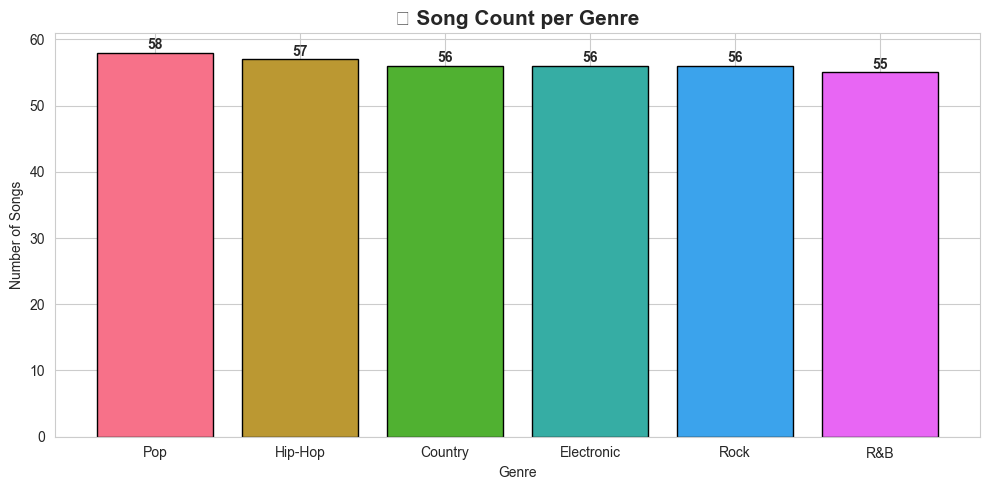

The dataset is fairly balanced across genres!


In [ ]:
# Genre distribution
genre_counts = df['genre'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(genre_counts.index, genre_counts.values,
               color=sns.color_palette('husl', len(genre_counts)), edgecolor='black')
plt.title('🎸 Song Count per Genre', fontsize=15, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
for bar, val in zip(bars, genre_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('The dataset is fairly balanced across genres!')

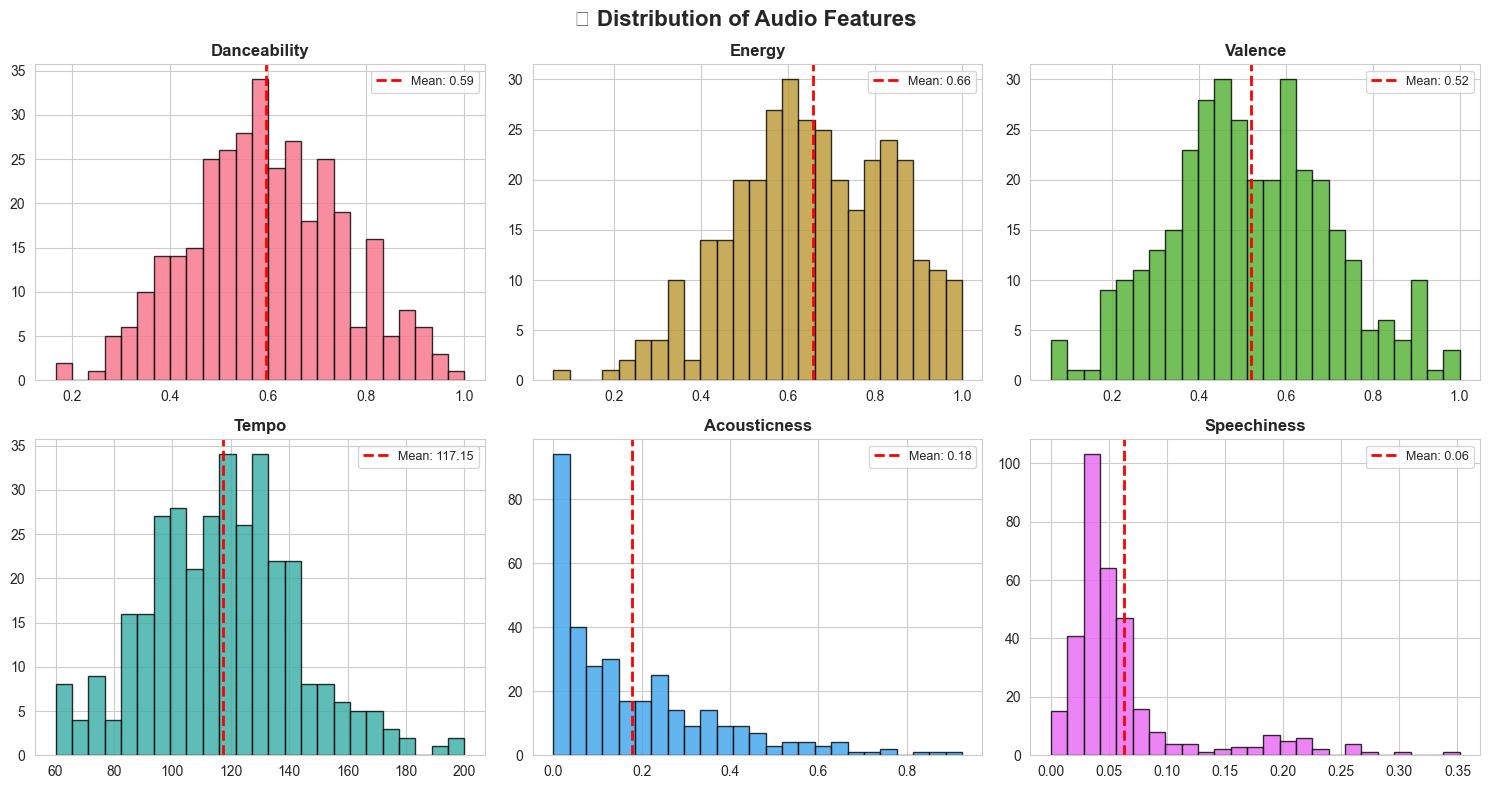

In [ ]:
# Distribution of all audio features
features = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('📈 Distribution of Audio Features', fontsize=16, fontweight='bold')

colors = sns.color_palette('husl', 6)
for i, (feat, ax, color) in enumerate(zip(features, axes.flatten(), colors)):
    ax.hist(df[feat], bins=25, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[feat].mean():.2f}')
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

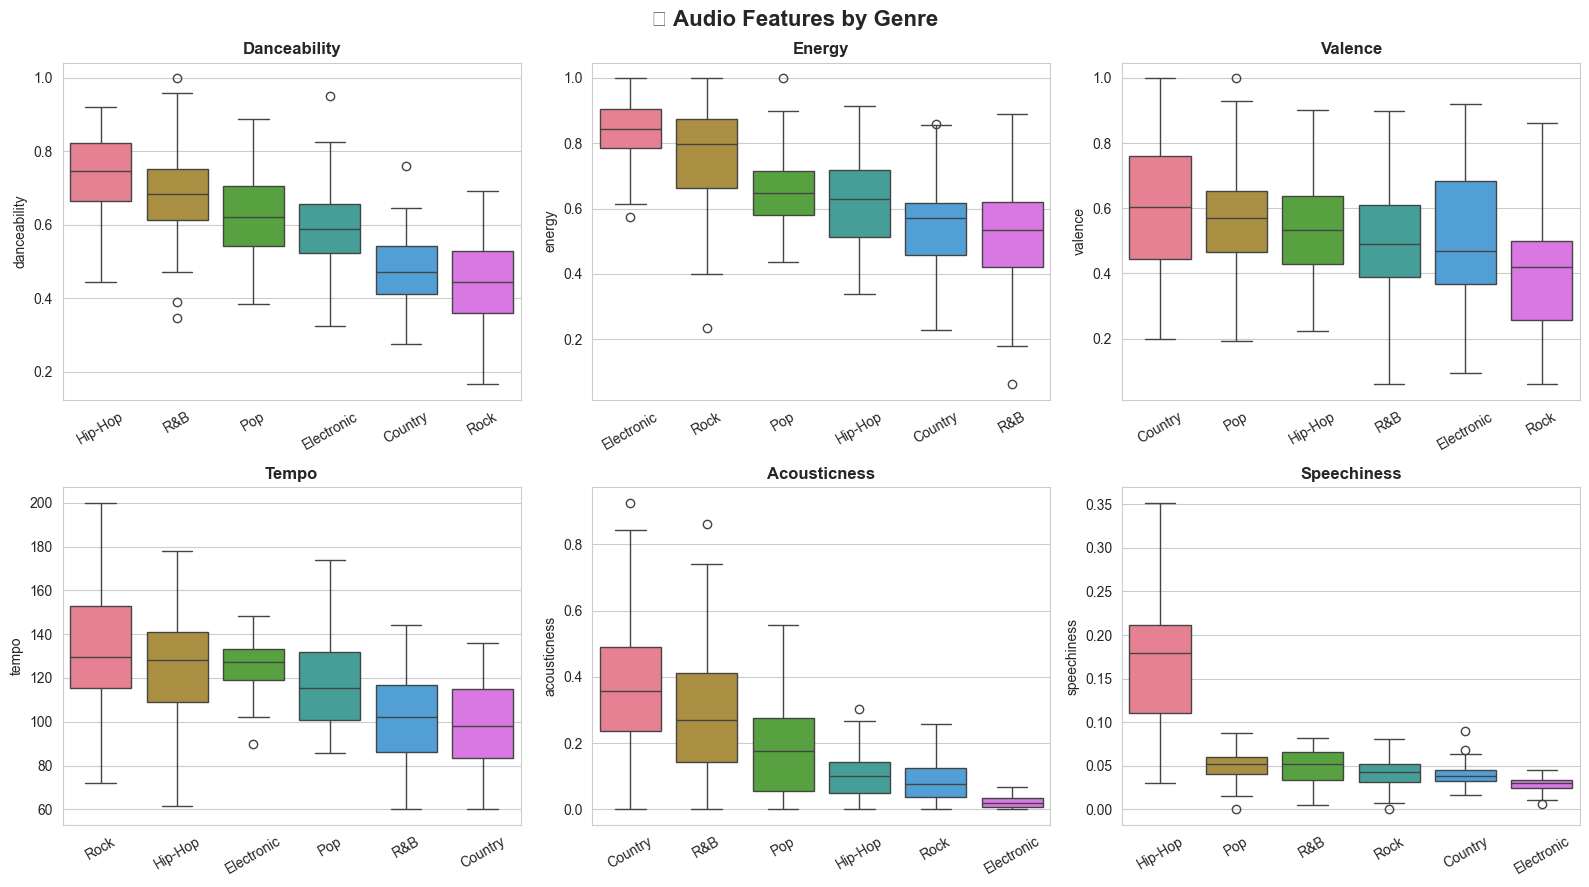

In [ ]:
# Box plots: Audio features by Genre
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('🎵 Audio Features by Genre', fontsize=16, fontweight='bold')

for feat, ax in zip(features, axes.flatten()):
    genre_order = df.groupby('genre')[feat].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='genre', y=feat, order=genre_order, ax=ax, palette='husl')
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

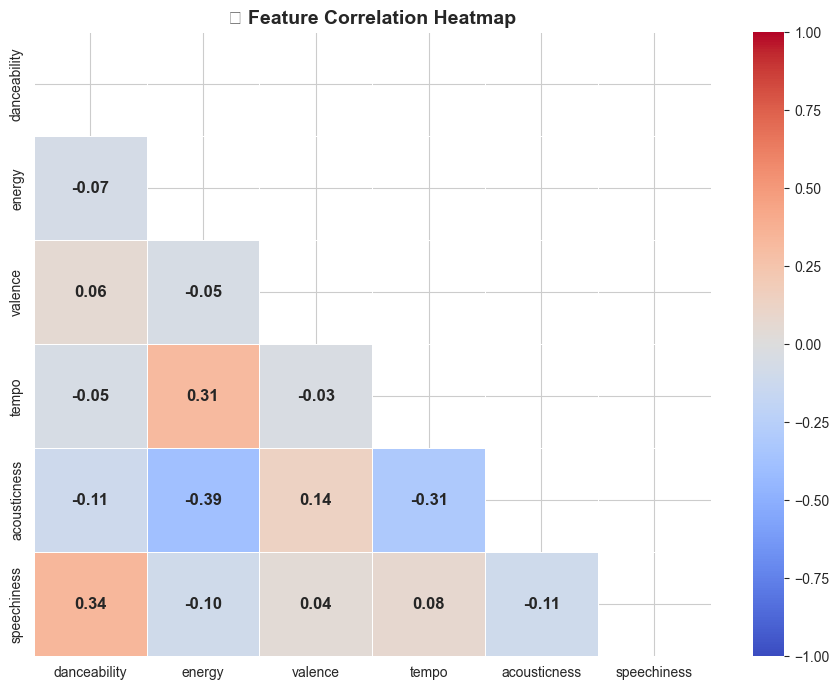

Key Observations:
• Energy & Acousticness are negatively correlated (louder songs are less acoustic)
• Danceability & speechiness are positively correlated (happier songs are more danceable)


In [ ]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
corr_matrix = df[features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('🔗 Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key Observations:')
print('• Energy & Acousticness are negatively correlated (louder songs are less acoustic)')
print('• Danceability & speechiness are positively correlated (happier songs are more danceable)')

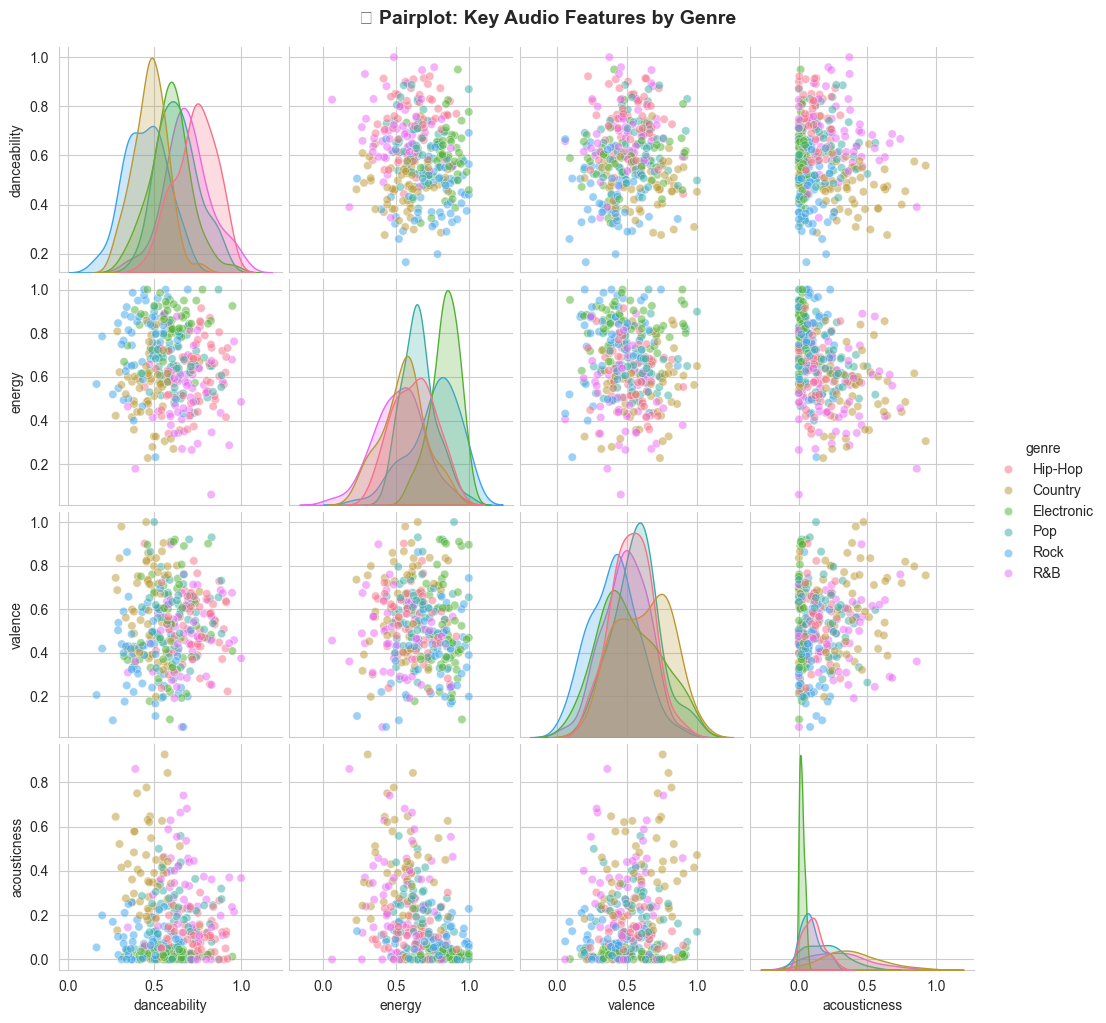

In [ ]:
# Pairplot of key features colored by genre
key_features = ['danceability', 'energy', 'valence', 'acousticness']
pair_df = df[key_features + ['genre']]

g = sns.pairplot(pair_df, hue='genre', plot_kws={'alpha': 0.5},
                 diag_kind='kde', height=2.5)
g.fig.suptitle('🎶 Pairplot: Key Audio Features by Genre', y=1.02, fontsize=14, fontweight='bold')
plt.show()

---
## ⚙️ Step 4: Feature Engineering & Preprocessing

### Why do we need to scale features?

K-Means uses **Euclidean distance** to measure how similar songs are.

| Feature | Range |
|---|---|
| tempo | 60 – 200 |
| danceability | 0.0 – 1.0 |

Without scaling, `tempo` (large numbers) would **dominate** the distance calculation, making `danceability` irrelevant! **StandardScaler** makes all features have mean=0 and std=1.

In [ ]:
# Select only the numerical audio features for clustering
feature_cols = ['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness']
X = df[feature_cols].copy()

print('Features selected for clustering:')
print(feature_cols)
print(f'\nFeature matrix shape: {X.shape}')

Features selected for clustering:
['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness']

Feature matrix shape: (338, 6)


In [ ]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print('Before Scaling (first 3 rows):')
print(X.head(3).to_string())
print('\nAfter Scaling (first 3 rows):')
print(X_scaled_df.head(3).round(3).to_string())
print(f'\nMean after scaling: {X_scaled_df.mean().round(4).tolist()}')
print(f'Std  after scaling: {X_scaled_df.std().round(4).tolist()}')

Before Scaling (first 3 rows):
   danceability  energy  valence     tempo  acousticness  speechiness
0        0.7269  0.3737   0.6478  104.8750        0.0666       0.0951
1        0.4749  0.5808   0.3868  132.1218        0.6463       0.0430
2        0.4778  0.7228   0.3313  130.8892        0.0449       0.0257

After Scaling (first 3 rows):
   danceability  energy  valence  tempo  acousticness  speechiness
0         0.849  -1.578    0.684 -0.478        -0.601        0.573
1        -0.772  -0.426   -0.720  0.583         2.532       -0.345
2        -0.754   0.364   -1.018  0.535        -0.718       -0.650

Mean after scaling: [0.0, 0.0, -0.0, -0.0, -0.0, 0.0]
Std  after scaling: [1.0015, 1.0015, 1.0015, 1.0015, 1.0015, 1.0015]


---
## 🔢 Step 5: Finding the Optimal Number of Clusters (K)

We don't know in advance how many clusters (groups) to create. We use two methods:

### Method 1: Elbow Method
- Train K-Means for different values of K (e.g., 1 to 12)
- Plot the **inertia** (sum of squared distances from each point to its cluster center)
- The "elbow" point where inertia stops decreasing sharply = optimal K

### Method 2: Silhouette Score
- Measures how well each song fits its own cluster vs. other clusters
- Score ranges from **-1 to 1** → higher is better
- Pick K with the highest silhouette score

In [ ]:
# Elbow Method + Silhouette Score
inertias = []
silhouette_scores = []
K_range = range(2, 13)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f'K={k:2d}  |  Inertia: {kmeans.inertia_:.1f}  |  Silhouette: {silhouette_score(X_scaled, labels):.4f}')

K= 2  |  Inertia: 1626.4  |  Silhouette: 0.1922
K= 3  |  Inertia: 1320.2  |  Silhouette: 0.2312
K= 4  |  Inertia: 1171.6  |  Silhouette: 0.2115
K= 5  |  Inertia: 1035.4  |  Silhouette: 0.1990
K= 6  |  Inertia: 957.6  |  Silhouette: 0.1922
K= 7  |  Inertia: 905.0  |  Silhouette: 0.1907
K= 8  |  Inertia: 851.9  |  Silhouette: 0.1816
K= 9  |  Inertia: 820.6  |  Silhouette: 0.1761
K=10  |  Inertia: 783.6  |  Silhouette: 0.1688
K=11  |  Inertia: 745.6  |  Silhouette: 0.1792
K=12  |  Inertia: 724.0  |  Silhouette: 0.1706


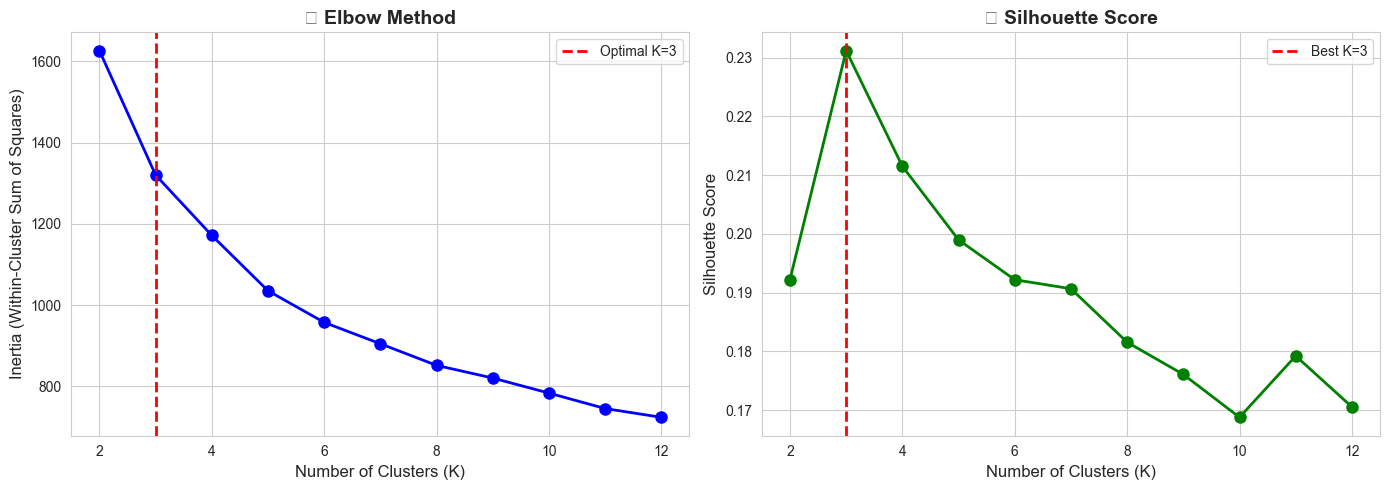

✅ Best K by Silhouette Score: K = 3


In [ ]:
# Plot both methods side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('📐 Elbow Method', fontsize=14, fontweight='bold')
best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
ax1.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={best_k}')
ax1.legend()
ax1.grid(True)

# Silhouette scores
ax2.plot(list(K_range), silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Best K={best_k}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('📊 Silhouette Score', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
print(f'✅ Best K by Silhouette Score: K = {best_k}')

---
## 🤖 Step 6: Train K-Means Clustering Model

### How K-Means Works:
1. **Initialize** K centroids (cluster centers) randomly
2. **Assign** each song to the nearest centroid
3. **Update** centroids to the mean of all songs in that cluster
4. **Repeat** steps 2-3 until centroids stop changing

![K-Means](https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif)

In [ ]:
# Train the final K-Means model
# Silhouette score peaks at K=3, but with 6 genres we also try K=6
# 🧠 Key Lesson: Choose K using both metrics AND domain knowledge!
OPTIMAL_K = best_k  # Data-driven choice from Silhouette analysis
print(f'Silhouette-optimal K = {OPTIMAL_K}')
print('Tip: Try OPTIMAL_K = 6 to align with the 6 music genres!')
print()
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f'K-Means trained with K = {OPTIMAL_K}')
print(f'\nNumber of songs per cluster:')
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    bar = '█' * (count // 2)
    print(f'  Cluster {cluster}: {count:3d} songs  {bar}')

Silhouette-optimal K = 3
Tip: Try OPTIMAL_K = 6 to align with the 6 music genres!

K-Means trained with K = 3

Number of songs per cluster:
  Cluster 0:  48 songs  ████████████████████████
  Cluster 1: 142 songs  ███████████████████████████████████████████████████████████████████████
  Cluster 2: 148 songs  ██████████████████████████████████████████████████████████████████████████


In [ ]:
# Cluster-wise feature averages (Cluster Profiles)
cluster_profiles = df.groupby('cluster')[feature_cols].mean().round(3)
print('🎨 Cluster Profiles (Average Feature Values):')
cluster_profiles

🎨 Cluster Profiles (Average Feature Values):


,danceability,energy,valence,tempo,acousticness,speechiness
cluster,,,,,,
0,0.749,0.631,0.542,123.735,0.101,0.182
1,0.593,0.528,0.532,101.633,0.320,0.045
2,0.547,0.790,0.503,129.913,0.066,0.040


In [ ]:
# What genre dominates each cluster?
print('🏆 Most Common Genre in Each Cluster:')
for c in range(OPTIMAL_K):
    top_genre = df[df['cluster'] == c]['genre'].value_counts().idxmax()
    genre_dist = df[df['cluster'] == c]['genre'].value_counts().to_dict()
    print(f'  Cluster {c} → Top Genre: {top_genre:12s} | Distribution: {genre_dist}')

🏆 Most Common Genre in Each Cluster:
  Cluster 0 → Top Genre: Hip-Hop      | Distribution: {'Hip-Hop': 46, 'Pop': 1, 'Country': 1}
  Cluster 1 → Top Genre: R&B          | Distribution: {'R&B': 51, 'Country': 50, 'Pop': 29, 'Rock': 7, 'Hip-Hop': 5}
  Cluster 2 → Top Genre: Electronic   | Distribution: {'Electronic': 56, 'Rock': 49, 'Pop': 28, 'Hip-Hop': 6, 'Country': 5, 'R&B': 4}


---
## 📉 Step 7: Visualize Clusters with PCA

We have **6 features** — impossible to visualize directly.
**PCA (Principal Component Analysis)** reduces dimensions to 2 or 3 while preserving maximum variance, so we can **plot and see the clusters!**

In [ ]:
# PCA: Reduce to 2 components
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

explained = pca2.explained_variance_ratio_
print(f'PC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC2 explains {explained[1]*100:.1f}% of variance')
print(f'Total variance captured: {sum(explained)*100:.1f}%')

PC1 explains 28.4% of variance
PC2 explains 23.2% of variance
Total variance captured: 51.6%


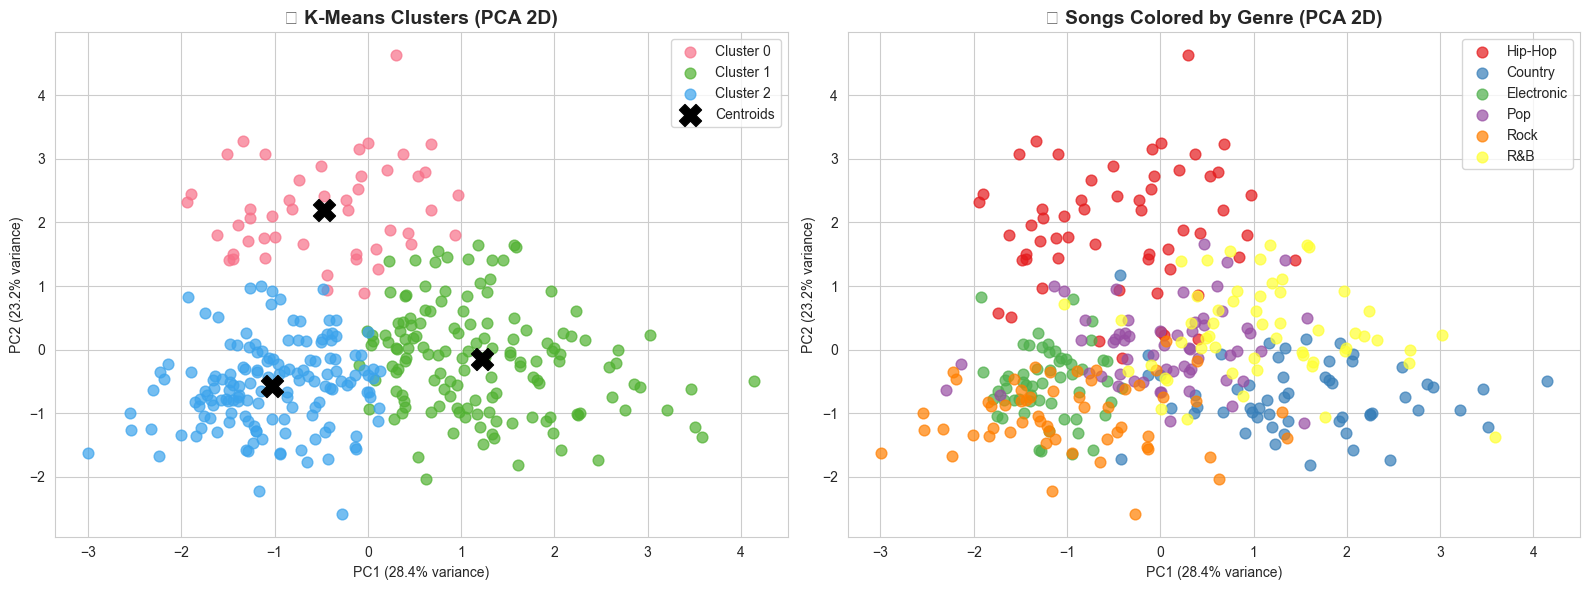

In [ ]:
# 2D Cluster visualization
colors = sns.color_palette('husl', OPTIMAL_K)
cluster_labels = [f'Cluster {i}' for i in range(OPTIMAL_K)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Colored by cluster
for c in range(OPTIMAL_K):
    mask = df['cluster'] == c
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    color=colors[c], label=f'Cluster {c}', alpha=0.7, s=60)

# Plot centroids
centroids_pca = pca2.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_title('🎯 K-Means Clusters (PCA 2D)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[0].legend(loc='upper right')

# Plot 2: Colored by genre
genres = df['genre'].unique()
genre_colors = sns.color_palette('Set1', len(genres))
for genre, color in zip(genres, genre_colors):
    mask = df['genre'] == genre
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    color=color, label=genre, alpha=0.7, s=60)
axes[1].set_title('🎸 Songs Colored by Genre (PCA 2D)', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

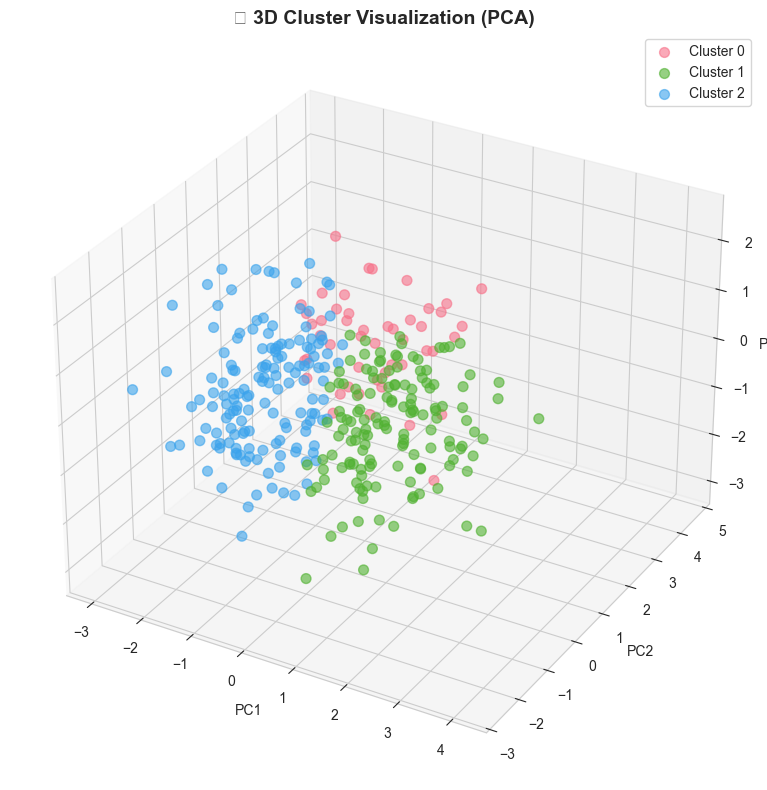

In [ ]:
# 3D Cluster visualization
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3, random_state=42)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for c in range(OPTIMAL_K):
    mask = df['cluster'] == c
    ax.scatter(X_pca3[mask, 0], X_pca3[mask, 1], X_pca3[mask, 2],
               color=colors[c], label=f'Cluster {c}', alpha=0.6, s=50)

ax.set_title('🌐 3D Cluster Visualization (PCA)', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()
plt.tight_layout()
plt.show()

KeyError: 3

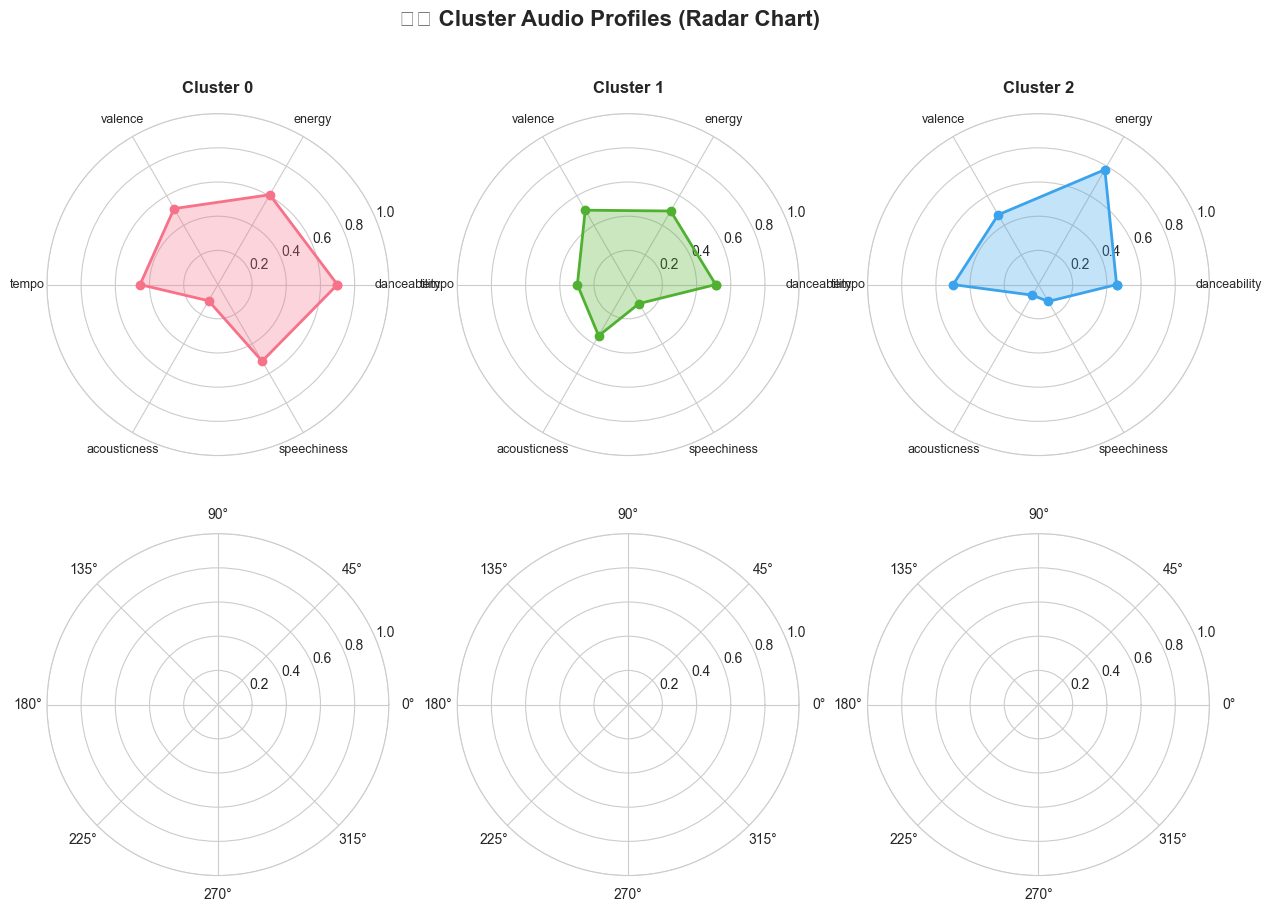

In [ ]:
# Radar/Spider chart of cluster profiles
from matplotlib.patches import FancyArrowPatch

# Normalize cluster profiles between 0 and 1 for radar
profile_norm = cluster_profiles.copy()
for col in profile_norm.columns:
    mn, mx = df[col].min(), df[col].max()
    profile_norm[col] = (profile_norm[col] - mn) / (mx - mn)

categories = feature_cols
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))
fig.suptitle('🕸️ Cluster Audio Profiles (Radar Chart)', fontsize=16, fontweight='bold')

for c, ax in enumerate(axes.flatten()):
    values = profile_norm.loc[c].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[c])
    ax.fill(angles, values, alpha=0.3, color=colors[c])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {c}', fontweight='bold', fontsize=12, pad=15)
    ax.grid(True)

plt.tight_layout()
plt.show()

---
## 🎯 Step 8: Name the Clusters (Interpret What They Mean)

Let's look at each cluster's audio profile and give them a music personality name!

This is an important step in any clustering project — **making the clusters meaningful** to stakeholders.

In [ ]:
# Interpret clusters based on feature values
print('=' * 70)
print('🎨 CLUSTER INTERPRETATIONS')
print('=' * 70)

for c in range(OPTIMAL_K):
    profile = cluster_profiles.loc[c]
    top_genre = df[df['cluster'] == c]['genre'].value_counts().idxmax()
    size = (df['cluster'] == c).sum()

    print(f'\n🔵 Cluster {c}  ({size} songs) — Top Genre: {top_genre}')
    print(f'   Danceability : {profile["danceability"]:.2f}  | Energy: {profile["energy"]:.2f}')
    print(f'   Valence      : {profile["valence"]:.2f}  | Tempo:  {profile["tempo"]:.0f} BPM')
    print(f'   Acousticness : {profile["acousticness"]:.2f}  | Speechiness: {profile["speechiness"]:.2f}')

    # Auto-label
    if profile['energy'] > 0.75 and profile['danceability'] > 0.65:
        label = '🔥 High Energy Dance'
    elif profile['acousticness'] > 0.4:
        label = '🎸 Acoustic / Chill'
    elif profile['valence'] > 0.65:
        label = '😊 Happy / Upbeat'
    elif profile['energy'] < 0.5 and profile['valence'] < 0.4:
        label = '😢 Sad / Slow'
    elif profile['speechiness'] > 0.08:
        label = '🎤 Rap / Spoken'
    else:
        label = '🎵 Balanced / Mainstream'
    print(f'   🏷️  Label: {label}')

print('\n' + '=' * 70)

🎨 CLUSTER INTERPRETATIONS

🔵 Cluster 0  (48 songs) — Top Genre: Hip-Hop
   Danceability : 0.75  | Energy: 0.63
   Valence      : 0.54  | Tempo:  124 BPM
   Acousticness : 0.10  | Speechiness: 0.18
   🏷️  Label: 🎤 Rap / Spoken

🔵 Cluster 1  (142 songs) — Top Genre: R&B
   Danceability : 0.59  | Energy: 0.53
   Valence      : 0.53  | Tempo:  102 BPM
   Acousticness : 0.32  | Speechiness: 0.04
   🏷️  Label: 🎵 Balanced / Mainstream

🔵 Cluster 2  (148 songs) — Top Genre: Electronic
   Danceability : 0.55  | Energy: 0.79
   Valence      : 0.50  | Tempo:  130 BPM
   Acousticness : 0.07  | Speechiness: 0.04
   🏷️  Label: 🎵 Balanced / Mainstream



---
## 🎵 Step 9: Build the Song Recommendation System

### How Recommendations Work:
1. User listens to a song → we find its **cluster**
2. We recommend other songs **from the same cluster** that the user hasn't heard
3. We can further sort by **distance to the centroid** — songs closer to the center are more "representative" of that cluster

This is essentially how Spotify's collaborative filtering and audio-based recommendations work!

In [ ]:
def recommend_songs(song_title, df, X_scaled, kmeans, scaler, n_recommendations=5):
    """
    Recommends similar songs based on K-Means cluster membership.

    Parameters:
    - song_title: Title of the song the user likes
    - df: DataFrame with songs and cluster assignments
    - X_scaled: Scaled feature matrix
    - kmeans: Trained K-Means model
    - scaler: Fitted StandardScaler
    - n_recommendations: How many songs to recommend

    Returns: DataFrame of recommended songs
    """
    # Step 1: Find the song
    song_matches = df[df['title'].str.contains(song_title, case=False, na=False)]
    if song_matches.empty:
        print(f"❌ Song '{song_title}' not found in the dataset.")
        return None

    seed_song = song_matches.iloc[0]
    song_cluster = seed_song['cluster']

    print(f"🎵 Song Found: '{seed_song['title']}'")
    print(f"   Artist : {seed_song['artist']}")
    print(f"   Genre  : {seed_song['genre']}")
    print(f"   Cluster: {song_cluster}")
    print(f"   Audio  → Dance:{seed_song['danceability']:.2f} | Energy:{seed_song['energy']:.2f} | "
          f"Valence:{seed_song['valence']:.2f} | Tempo:{seed_song['tempo']:.0f}")

    # Step 2: Get all songs in the same cluster (excluding the seed song)
    cluster_songs = df[(df['cluster'] == song_cluster) &
                       (df['title'] != seed_song['title'])].copy()

    # Step 3: Calculate distance from each song to the seed song
    seed_idx = song_matches.index[0]
    seed_vector = X_scaled[seed_idx]

    cluster_indices = cluster_songs.index.tolist()
    distances = np.linalg.norm(X_scaled[cluster_indices] - seed_vector, axis=1)
    cluster_songs['similarity_distance'] = distances

    # Step 4: Return top N most similar songs
    recommendations = cluster_songs.sort_values('similarity_distance').head(n_recommendations)

    print(f"\n✅ Top {n_recommendations} Recommended Songs from Cluster {song_cluster}:")
    print('-' * 70)
    return recommendations[['title', 'artist', 'genre', 'danceability',
                             'energy', 'valence', 'tempo', 'similarity_distance']].reset_index(drop=True)

print('✅ Recommendation function defined!')

✅ Recommendation function defined!


In [ ]:
# Try the recommendation system!
# Pick a random song as the "user's favorite"
sample_song = df.sample(1, random_state=7)['title'].values[0]
print(f"🎧 User is listening to: '{sample_song}'\n")

recommendations = recommend_songs(
    song_title=sample_song,
    df=df,
    X_scaled=X_scaled,
    kmeans=kmeans,
    scaler=scaler,
    n_recommendations=5
)
recommendations

🎧 User is listening to: 'Synthetic_Country_1'

🎵 Song Found: 'Synthetic_Country_13'
   Artist : Synthetic
   Genre  : Country
   Cluster: 1
   Audio  → Dance:0.55 | Energy:0.57 | Valence:0.36 | Tempo:73

✅ Top 5 Recommended Songs from Cluster 1:
----------------------------------------------------------------------


,title,artist,genre,danceability,energy,valence,tempo,similarity_distance
0,Synthetic_Country_9,Synthetic,Country,0.5751,0.6293,0.3379,83.5131,0.954517
1,Synthetic_Pop_41,Synthetic,Pop,0.5248,0.6477,0.2636,85.7250,1.099609
2,Synthetic_R&B_21,Synthetic,R&B,0.5887,0.4303,0.5062,68.6165,1.263663
3,Synthetic_Country_44,Synthetic,Country,0.4169,0.5806,0.4083,82.4479,1.323143
4,Synthetic_Country_49,Synthetic,Country,0.5502,0.7223,0.3215,97.8419,1.367412


In [ ]:
# Try another song — test with different genres!
print('--- Test 2: Rock Song ---')
rock_song = df[df['genre'] == 'Rock'].sample(1, random_state=3)['title'].values[0]
recs2 = recommend_songs(rock_song, df, X_scaled, kmeans, scaler, n_recommendations=5)
recs2

--- Test 2: Rock Song ---
🎵 Song Found: 'Synthetic_Rock_6'
   Artist : Synthetic
   Genre  : Rock
   Cluster: 2
   Audio  → Dance:0.46 | Energy:0.85 | Valence:0.63 | Tempo:174

✅ Top 5 Recommended Songs from Cluster 2:
----------------------------------------------------------------------


,title,artist,genre,danceability,energy,valence,tempo,similarity_distance
0,Good 4 U,Olivia Rodrigo,Pop,0.5600,0.8900,0.6700,166.0000,0.964745
1,As It Was,Harry Styles,Pop,0.5200,0.7300,0.5600,174.0000,0.983867
2,Synthetic_Rock_42,Synthetic,Rock,0.5168,0.7224,0.6034,156.8455,1.052400
3,Synthetic_Rock_49,Synthetic,Rock,0.5336,0.7589,0.6957,156.2103,1.082047
4,Synthetic_Rock_3,Synthetic,Rock,0.5267,0.6867,0.5977,160.4102,1.289783


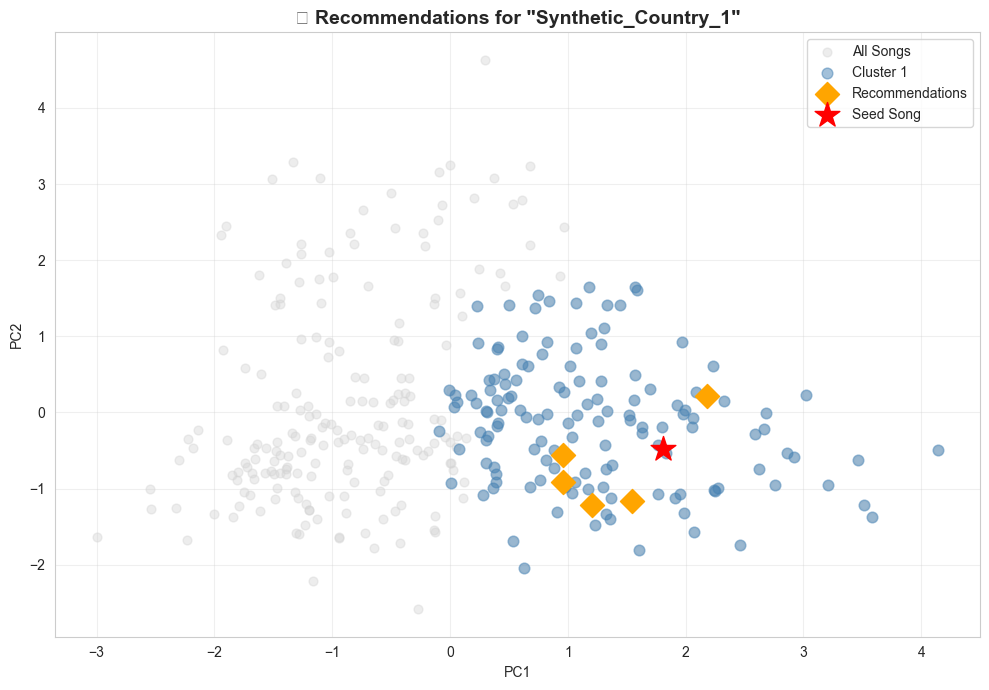

In [ ]:
# Visualize: Where is the seed song vs recommendations in PCA space?
def visualize_recommendations(song_title, df, X_pca2, recommendations):
    seed_idx = df[df['title'].str.contains(song_title, case=False)].index[0]
    rec_idx = df[df['title'].isin(recommendations['title'])].index.tolist()
    seed_cluster = df.loc[seed_idx, 'cluster']

    plt.figure(figsize=(10, 7))

    # All songs (gray)
    plt.scatter(X_pca2[:, 0], X_pca2[:, 1], color='lightgray', alpha=0.4, s=40, label='All Songs')

    # Same cluster songs (light blue)
    cluster_mask = df['cluster'] == seed_cluster
    plt.scatter(X_pca2[cluster_mask, 0], X_pca2[cluster_mask, 1],
                color='steelblue', alpha=0.5, s=60, label=f'Cluster {seed_cluster}')

    # Recommendations (orange)
    plt.scatter(X_pca2[rec_idx, 0], X_pca2[rec_idx, 1],
                color='orange', s=150, zorder=5, label='Recommendations', marker='D')

    # Seed song (red star)
    plt.scatter(X_pca2[seed_idx, 0], X_pca2[seed_idx, 1],
                color='red', s=350, zorder=6, label='Seed Song', marker='*')

    plt.title(f'🎯 Recommendations for "{song_title}"', fontsize=14, fontweight='bold')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_recommendations(sample_song, df, X_pca2, recommendations)

---
## 🎯 Step 9b: Personalized Recommendation (Using Listening History)

Now we upgrade our recommender:

1. **Input**: a `customer_id`
2. **Find**: songs the customer has already listened to → identify their **preferred clusters**
3. **Recommend**: songs from those preferred clusters that the customer has **NOT listened to yet**
4. **Rank**: by similarity distance — closest songs first

> This is exactly how Spotify works:
> - Listened songs tell us the user's taste cluster
> - We recommend unheard songs from the same cluster

```
Customer listens to songs  →  songs belong to clusters  →
find preferred cluster     →  recommend UNHEARD songs from that cluster
```

In [ ]:
def recommend_for_customer(customer_id, full_df, X_scaled, df_songs, n_recommendations=5):
    """
    Recommends songs a customer has NOT listened to yet,
    based on their listening history and K-Means clusters.

    Parameters:
    - customer_id     : e.g. 'CUST_001'
    - full_df         : merged DataFrame with customer_id, title, listened, cluster
    - X_scaled        : scaled feature matrix aligned with df_songs
    - df_songs        : the original songs DataFrame (with index aligned to X_scaled)
    - n_recommendations: how many songs to suggest

    Returns: DataFrame of recommended songs
    """
    customer_data = full_df[full_df['customer_id'] == customer_id]
    if customer_data.empty:
        print(f'Customer {customer_id} not found.')
        return None

    # Step A: Listened & not-listened songs
    listened_songs     = customer_data[customer_data['listened'] == 1]['title'].tolist()
    not_listened_songs = customer_data[customer_data['listened'] == 0]['title'].tolist()

    print(f'Customer     : {customer_id}')
    print(f'Listened     : {len(listened_songs)} songs')
    print(f'Not Listened : {len(not_listened_songs)} songs  (these are recommendation candidates)')

    # Step B: Find preferred clusters (clusters of listened songs)
    listened_df   = df_songs[df_songs['title'].isin(listened_songs)]
    cluster_votes = listened_df['cluster'].value_counts()
    preferred_cluster = cluster_votes.idxmax()

    print(f'\nPreferred Cluster: Cluster {preferred_cluster}')
    print(f'Cluster vote counts from listening history:')
    for cl, cnt in cluster_votes.items():
        bar = '|' * cnt
        print(f'  Cluster {cl}: {cnt:3d} songs {bar}')

    # Step C: Candidate songs = NOT listened + in preferred cluster
    candidates = df_songs[
        (df_songs['title'].isin(not_listened_songs)) &
        (df_songs['cluster'] == preferred_cluster)
    ].copy()

    if candidates.empty:
        print('No unheard songs in preferred cluster. Expanding to all clusters...')
        candidates = df_songs[df_songs['title'].isin(not_listened_songs)].copy()

    # Step D: Rank candidates by avg distance to listened songs in the preferred cluster
    listened_cluster_idx = listened_df[listened_df['cluster'] == preferred_cluster].index.tolist()
    if not listened_cluster_idx:
        listened_cluster_idx = listened_df.index.tolist()

    centroid_vector = X_scaled[listened_cluster_idx].mean(axis=0)
    candidate_idx   = candidates.index.tolist()
    distances = np.linalg.norm(X_scaled[candidate_idx] - centroid_vector, axis=1)
    candidates['similarity_score'] = distances

    recommendations = candidates.sort_values('similarity_score').head(n_recommendations)

    print(f'\nTop {n_recommendations} Recommended Songs (never heard before):')
    print('-' * 65)
    return recommendations[['title', 'genre', 'cluster', 'danceability',
                             'energy', 'valence', 'similarity_score']].reset_index(drop=True)

print('Personalized recommendation function defined!')

In [ ]:
# Recommend for CUST_001
recs_001 = recommend_for_customer('CUST_001', full_df, X_scaled, df, n_recommendations=5)
recs_001

In [ ]:
# Recommend for CUST_005
print('=== Recommendations for CUST_005 ===')
recs_005 = recommend_for_customer('CUST_005', full_df, X_scaled, df, n_recommendations=5)
print(recs_005)

print()
print('=== Recommendations for CUST_010 ===')
recs_010 = recommend_for_customer('CUST_010', full_df, X_scaled, df, n_recommendations=5)
print(recs_010)

In [ ]:
# Visualize: Listening history vs Recommendations on PCA map
def visualize_customer_recommendations(customer_id, full_df, df_songs, X_pca2, recommendations):
    customer_data  = full_df[full_df['customer_id'] == customer_id]
    listened_songs = customer_data[customer_data['listened'] == 1]['title'].tolist()

    listened_idx = df_songs[df_songs['title'].isin(listened_songs)].index.tolist()
    rec_idx      = df_songs[df_songs['title'].isin(recommendations['title'])].index.tolist()

    plt.figure(figsize=(11, 7))

    # All unheard songs (gray)
    all_idx = df_songs.index.tolist()
    plt.scatter(X_pca2[:, 0], X_pca2[:, 1],
                color='lightgray', alpha=0.35, s=35, label='All Songs (Unheard)')

    # Listened songs (blue)
    plt.scatter(X_pca2[listened_idx, 0], X_pca2[listened_idx, 1],
                color='steelblue', alpha=0.6, s=60, label=f'Listened ({len(listened_idx)} songs)')

    # Recommendations (orange diamonds)
    plt.scatter(X_pca2[rec_idx, 0], X_pca2[rec_idx, 1],
                color='orange', s=200, zorder=5,
                label=f'Recommended ({len(rec_idx)} songs)', marker='D', edgecolors='black')

    # Label recommended songs
    for idx in rec_idx:
        song_name = df_songs.loc[idx, 'title']
        short_name = song_name[:20] + '...' if len(song_name) > 20 else song_name
        plt.annotate(short_name,
                     (X_pca2[idx, 0], X_pca2[idx, 1]),
                     textcoords='offset points', xytext=(8, 4),
                     fontsize=8, color='darkorange', fontweight='bold')

    plt.title(f'Personalized Recommendations for {customer_id}\n(Orange = New songs to discover!)',
              fontsize=13, fontweight='bold')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_customer_recommendations('CUST_001', full_df, df, X_pca2, recs_001)

In [ ]:
# Batch: Generate recommendations for ALL customers
print('=== Batch Recommendations for All Customers ===')
print('=' * 65)

all_recommendations = {}
for cid_num in range(1, NUM_CUSTOMERS + 1):
    cid = f'CUST_{cid_num:03d}'
    cust_data = full_df[full_df['customer_id'] == cid]
    listened   = cust_data[cust_data['listened'] == 1]['title'].tolist()
    candidates = df[df['title'].isin(cust_data[cust_data['listened'] == 0]['title'].tolist())]
    listened_df = df[df['title'].isin(listened)]
    pref_cluster = listened_df['cluster'].value_counts().idxmax()
    cands_in_cluster = candidates[candidates['cluster'] == pref_cluster]
    c_idx = cands_in_cluster.index.tolist()
    l_idx = listened_df[listened_df['cluster'] == pref_cluster].index.tolist()
    if l_idx:
        centroid = X_scaled[l_idx].mean(axis=0)
        dists = np.linalg.norm(X_scaled[c_idx] - centroid, axis=1)
        cands_in_cluster = cands_in_cluster.copy()
        cands_in_cluster['dist'] = dists
        top3 = cands_in_cluster.sort_values('dist').head(3)['title'].tolist()
    else:
        top3 = cands_in_cluster.head(3)['title'].tolist()
    all_recommendations[cid] = top3
    print(f'{cid} (Pref Cluster {pref_cluster}): {top3}')

# Save to CSV
rec_rows = []
for cid, songs in all_recommendations.items():
    for rank, song in enumerate(songs, 1):
        rec_rows.append({'customer_id': cid, 'rank': rank, 'recommended_song': song})

rec_out = pd.DataFrame(rec_rows)
rec_out.to_csv('customer_recommendations.csv', index=False)
print()
print('Recommendations saved to: customer_recommendations.csv')
rec_out

=== Batch Recommendations for All Customers ===


NameError: name 'NUM_CUSTOMERS' is not defined

---
## 📊 Step 10: Model Evaluation

How good is our clustering? We use:

| Metric | What it measures | Better when |
|---|---|---|
| **Inertia** | Compactness of clusters (within-cluster distance) | Lower |
| **Silhouette Score** | How well-separated clusters are | Higher (max 1.0) |
| **Genre Purity** | How much each cluster is dominated by one genre | Higher |

In [ ]:
# Evaluation metrics
final_labels = df['cluster'].values
final_inertia = kmeans.inertia_
final_silhouette = silhouette_score(X_scaled, final_labels)

print('=' * 50)
print('📊 MODEL EVALUATION RESULTS')
print('=' * 50)
print(f'  Number of Clusters : {OPTIMAL_K}')
print(f'  Inertia            : {final_inertia:.2f}')
print(f'  Silhouette Score   : {final_silhouette:.4f}')

if final_silhouette > 0.3:
    print(f'  Interpretation     : ✅ Good cluster structure!')
elif final_silhouette > 0.1:
    print(f'  Interpretation     : ⚠️ Moderate cluster structure')
else:
    print(f'  Interpretation     : ❌ Weak cluster structure')
print('=' * 50)

📊 MODEL EVALUATION RESULTS
  Number of Clusters : 3
  Inertia            : 1320.20
  Silhouette Score   : 0.2312
  Interpretation     : ⚠️ Moderate cluster structure


In [ ]:
# Genre Purity per cluster
print('🏆 Genre Purity per Cluster:')
print('-' * 50)
purities = []
for c in range(OPTIMAL_K):
    cluster_df = df[df['cluster'] == c]
    top_genre_count = cluster_df['genre'].value_counts().iloc[0]
    purity = top_genre_count / len(cluster_df) * 100
    purities.append(purity)
    top_genre = cluster_df['genre'].value_counts().idxmax()
    print(f'  Cluster {c}: {purity:.1f}% {top_genre}')

print(f'\n  Average Genre Purity: {np.mean(purities):.1f}%')
print('\n  Note: ~17% = random (6 genres). Higher = better clustering!')

🏆 Genre Purity per Cluster:
--------------------------------------------------
  Cluster 0: 95.8% Hip-Hop
  Cluster 1: 35.9% R&B
  Cluster 2: 37.8% Electronic

  Average Genre Purity: 56.5%

  Note: ~17% = random (6 genres). Higher = better clustering!


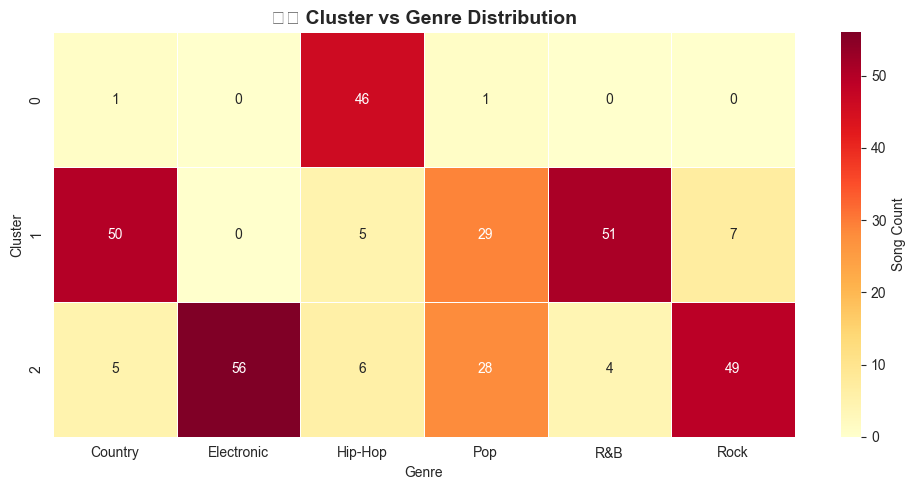

In [ ]:
# Final heatmap: Cluster vs Genre
cluster_genre = pd.crosstab(df['cluster'], df['genre'])

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_genre, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Song Count'})
plt.title('🗺️ Cluster vs Genre Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

---
## 💾 Step 11: Save Results

Save the clustered dataset and the model for future use.

In [ ]:
import pickle

# Save clustered dataset
df.to_csv('spotify_clustered.csv', index=False)
print('✅ Clustered dataset saved to: spotify_clustered.csv')

# Save model and scaler
with open('spotify_kmeans_model.pkl', 'wb') as f:
    pickle.dump({'kmeans': kmeans, 'scaler': scaler, 'pca': pca2}, f)
print('✅ Model saved to: spotify_kmeans_model.pkl')

# Preview saved data
print('\nFinal Dataset Preview:')
df[['title', 'genre', 'cluster', 'danceability', 'energy', 'valence']].head(8)

---
## 🏁 Step 12: Summary & Conclusions

### What We Built
A **Spotify-style music recommendation system** using **unsupervised machine learning (K-Means Clustering)**.

### Key Learnings

| Concept | What We Did |
|---|---|
| **EDA** | Explored distributions, correlations, genre breakdowns |
| **Feature Scaling** | Used StandardScaler so no feature dominates |
| **Elbow Method** | Found the right number of clusters (K) |
| **Silhouette Score** | Validated cluster quality |
| **K-Means Clustering** | Grouped songs by audio similarity |
| **PCA** | Visualized high-dimensional clusters in 2D/3D |
| **Recommendation Engine** | Recommended similar songs from the same cluster |

### How This Relates to Real Spotify
- Spotify uses **collaborative filtering** (user behavior) + **audio features** (what we used)
- They cluster **hundreds of millions of songs** and users using similar ideas, just at massive scale
- The core idea is the same: **find what's similar → recommend from the same group**

### 🚀 Ideas to Extend This Project
1. **User-based clustering**: Cluster users by their listening history, not just songs
2. **Try other algorithms**: DBSCAN, Gaussian Mixture Models, Hierarchical Clustering
3. **Add more features**: Song duration, key, mode (major/minor)
4. **Build a web app**: Use Streamlit/Flask to make a live recommendation UI
5. **Use real Spotify API**: Fetch actual user listening data via Spotipy library

---
### 📚 Concepts Covered
- Unsupervised Learning
- K-Means Clustering
- Principal Component Analysis (PCA)
- Feature Scaling (StandardScaler)
- Elbow Method
- Silhouette Score
- Recommendation Systems
- Data Visualization with Seaborn & Matplotlib